In [1]:
setwd("C:/Users/Snigdha/Downloads")
list.files(pattern="pinnacle", ignore.case=TRUE)

[1] "pinnacle_customers.csv" "pinnacle_products.csv"

In [3]:
# Question 1A - Identify the 10 products with the lowest STR. What do these products have in common?

products <- read.csv("pinnacle_products.csv", stringsAsFactors = FALSE)

wk6 <- products[products$week == 6, ]
wk6$STR <- wk6$cumulative_sold / wk6$initial_stock

wk6_sorted <- wk6[order(wk6$STR), ]
bottom10 <- wk6_sorted[1:10, ]

bottom10_view <- bottom10[, c("sku_id","product_name","category","brand",
                             "initial_price","current_price",
                             "initial_stock","cumulative_sold","STR",
                             "web_visits","competitor_price")]
bottom10_view

table(bottom10_view$category)
summary(bottom10_view$initial_price)
summary(bottom10_view$current_price)
summary(bottom10_view$web_visits)
summary(bottom10_view$current_price - bottom10_view$competitor_price)

,sku_id,product_name,category,brand,initial_price,current_price,initial_stock,cumulative_sold,STR,web_visits,competitor_price
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>,<dbl>
2286,SKU-0191,WildEdge First Aid Kit,Accessories,WildEdge,230.74,230.74,102,11,0.1078431,112,223.78
1938,SKU-0162,TrailBlaze Dry Bag,Accessories,TrailBlaze,212.10,175.23,68,9,0.1323529,39,203.90
1458,SKU-0122,OuterBound Trail Shoes,Hiking,OuterBound,271.87,271.87,88,13,0.1477273,65,240.27
2814,SKU-0235,SummitPro First Aid Kit II,Accessories,SummitPro,200.57,200.57,64,12,0.1875000,63,218.61
786,SKU-0066,TrailBlaze Mattress Pad,Camping,TrailBlaze,223.95,223.95,57,11,0.1929825,42,255.47
258,SKU-0022,TrailBlaze Insect Repellent,Accessories,TrailBlaze,26.01,26.01,118,24,0.2033898,112,24.89
174,SKU-0015,AlpineCore Water Bottle,Accessories,AlpineCore,191.77,191.77,115,24,0.2086957,97,164.81
270,SKU-0023,PeakGear Paracord,Accessories,PeakGear,167.69,142.39,86,18,0.2093023,47,149.40
1206,SKU-0101,WildEdge Camp Towel,Accessories,WildEdge,140.75,140.75,84,18,0.2142857,65,124.49



Accessories     Camping      Hiking 
          7           1           2 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  26.01  153.61  196.17  181.44  220.99  271.87 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  26.01  141.16  183.50  169.79  218.10  271.87 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  39.00   50.75   64.00   70.40   89.00  112.00 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
-53.410 -26.012  -2.945  -5.575  13.935  31.600 

# Question 1A - What do these products have in common?I computed sell through rate (STR) at week 6 using STR = cumulative_sold / initial stock.
The 10 products with the lowest STR are shown in my analysis above.

Category - Most of the lowest STR products are Accessories (7/10). The rest are Hiking (2/10) and Camping (1/10).
Price Range - Prices are usually mid to high level (from $26 - $272, with most being around $155 - $221). 
Other Patterns - The web visits are average (median is about 64). Their price is generally within a few dollars of competitors. 



In [18]:
# Question 1b - What does the price comparison suggest on why these products are underperforming. 

p <- read.csv("pinnacle_products.csv", stringsAsFactors = FALSE)

wk6 <- p[p$week == 6, ]
wk6$STR <- wk6$cumulative_sold / wk6$initial_stock

low <- wk6[wk6$STR < 0.40, ]
high_mean <- aggregate(current_price ~ category, wk6[wk6$STR > 0.70, ], mean)

out <- merge(low, high_mean, by="category", all.x=TRUE)
out$price_diff <- out$current_price.x - out$current_price.y

out[, c("sku_id","product_name","category","STR","current_price.x","current_price.y","price_diff")][order(out$price_diff, decreasing=TRUE), ]
summary(out$price_diff)

,sku_id,product_name,category,STR,current_price.x,current_price.y,price_diff
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>
52,SKU-0150,AlpineCore Water Filter II,Hiking,0.3809524,287.15,157.4449,129.70514
4,SKU-0136,AlpineCore Multi-Tool,Accessories,0.2500000,289.72,165.5880,124.13200
56,SKU-0122,OuterBound Trail Shoes,Hiking,0.1477273,271.87,157.4449,114.42514
40,SKU-0036,TrailBlaze Tarp,Camping,0.2682927,262.53,149.5982,112.93182
46,SKU-0061,AlpineCore Gaiters,Hiking,0.3577982,265.02,157.4449,107.57514
21,SKU-0245,TrailBlaze Neck Gaiter II,Accessories,0.3728814,267.99,165.5880,102.40200
12,SKU-0016,OuterBound Paracord,Accessories,0.3400000,267.87,165.5880,102.28200
60,SKU-0172,AlpineCore Hydration Pack,Hiking,0.3157895,258.51,157.4449,101.06514
33,SKU-0240,BaseCamp Base Layer,Apparel,0.2600000,234.18,138.5274,95.65262


    Min.  1st Qu.   Median     Mean  3rd Qu.     Max. 
-141.488  -44.631    4.469    5.612   68.192  129.705 

# Question 1b - Price Comparison

For week 6, I compared each product that underperformed (STR being below 40%), to the average current price of products in the same category that performed well (STR being above 70%). 

Price_diff = underperformer current price - mean current price of STR over 70% products in the same cateogory

Analysis - The price differences are mixed. The median price difference is around 4.5 and the mean is about 5.6. This means underperformers are slightly more expensive on average and even priced higher than successful products. 

Based on this analysis, it is safe to say that pricing is contributor for many underperforming products, especially the ones priced far above the successful group's category average. There may be other factors like product appeal, low demand and traffic that could also be the reason fort a low STR. 


In [30]:
# Question 1c - Linear Regression Model

data <- read.csv("pinnacle_products.csv", stringsAsFactors = FALSE)
names(data) <- trimws(names(data))

# we now have to put each product in order by week
data <- data[order(data$sku_id, data$week), ]

data$units_sold <- ave(data$cumulative_sold, data$sku_id,
                       FUN = function(x) c(x[1], diff(x)))

data$category <- as.factor(data$category)

#Now we build the model
model <- lm(units_sold ~ current_price + week + category + web_visits + competitor_price,
            data = data)
summary(model)


Call:
lm(formula = units_sold ~ current_price + week + category + web_visits + 
    competitor_price, data = data)

Residuals:
    Min      1Q  Median      3Q     Max 
-18.847  -2.978  -0.243   2.597  42.606 

Coefficients:
                   Estimate Std. Error t value Pr(>|t|)    
(Intercept)       7.5388809  0.3215366  23.446  < 2e-16 ***
current_price    -0.0108998  0.0031171  -3.497 0.000477 ***
week             -0.7328120  0.0252905 -28.976  < 2e-16 ***
categoryApparel  -0.2295426  0.2640024  -0.869 0.384647    
categoryCamping   0.2975886  0.2357065   1.263 0.206837    
categoryHiking    0.1946350  0.2404814   0.809 0.418364    
web_visits        0.0200185  0.0008624  23.212  < 2e-16 ***
competitor_price  0.0088450  0.0029586   2.990 0.002813 ** 
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Residual standard error: 4.961 on 3592 degrees of freedom
Multiple R-squared:  0.3174,	Adjusted R-squared:  0.316 
F-statistic: 238.6 on 7 and 3592 DF,  p-value: < 2.2

 # Question 1c - Report the model summary and interpret the coefficients on current_price and web_visits

 The coefficent of current_price is -0.0109 and p-value is 0.00048. This shows that higher prices slightly reduce sales. 
 The coefficient of web_visits is 0.02 and the p-value is 2e-16. This meabs that each additional web visit is associated with 0.02 more units sold. Based on this, we can safely assume online traffic is a huge contributor to driving sales. 

# Question 1d - Recommend a markdown strategy for the 10 worst-performing products

If current price is above the category's "successful" average price (1b), cut it down to that level. 
Main targets - Accessories = $165.59, Camping = $149.60, Hiking = $157.44.
If it is already below the target, do a 10% markdown instead. 

For each product, I compared revenue on the remaining inventory at week 6...
    Remaining units = initial_stock - cumulative_sold
    Liquidation Revenue = (0.25 x initial_price) x (remaining units)
    Markdown Revenue = (markdown price) x (remaining units)
Based on this comparison, markdown revenue is expected to be higher than liquidation revenue for the worst performing products. 

Is liquidation a better option for some products?
It  would be a batter option for some products. If a product is already priced at or below the category target price but still has low STR, the price isn't the main issue. For those specific products, if a markdown does not improve sales quickly, liquidation may be the better option to avoid carrying inventory that hasn't been sold. 



In [36]:
# Question 2a - Fit a logistic regression model prediciting churned using all available customer features without customer_id

cust <- read.csv("pinnacle_customers.csv", stringsAsFactors = FALSE)
names(cust) <- trimws(names(cust))

x <- cust[, names(cust) != "customer_id"]

m <- glm(churned ~ ., data = x, family = binomial)
summary(m)

p <- predict(m, type = "response")
pred <- ifelse(p >= 0.5, 1, 0)

accuracy <- mean(pred == x$churned)
base_churn <- mean(x$churned)
baseline_accuracy <- max(base_churn, 1 - base_churn)

accuracy
base_churn
baseline_accuracy


Call:
glm(formula = churned ~ ., family = binomial, data = x)

Coefficients:
                           Estimate Std. Error z value Pr(>|z|)    
(Intercept)              -1.061e+00  7.016e-01  -1.512 0.130628    
age                       7.028e-03  1.031e-02   0.682 0.495504    
income                   -6.590e-06  5.082e-06  -1.297 0.194703    
household_size           -2.181e-02  7.220e-02  -0.302 0.762610    
years_member             -3.805e-02  6.447e-02  -0.590 0.555091    
membership_tierGold      -6.020e-01  4.732e-01  -1.272 0.203289    
membership_tierSilver    -4.513e-01  2.270e-01  -1.988 0.046821 *  
distance_to_store         1.791e-02  1.134e-02   1.579 0.114335    
total_spent_12mo         -3.924e-01  1.562e+01  -0.025 0.979962    
num_purchases_12mo        4.645e-02  4.332e-02   1.072 0.283649    
avg_order_value           1.296e-03  1.324e-03   0.979 0.327614    
spend_camping             3.914e-01  1.562e+01   0.025 0.980015    
spend_hiking              3.925e-01  1

[1] 0.9245

[1] 0.0755

[1] 0.9245

# Question 2a - Compute the accuracy of the model using a 0.5 probability threshold. Is this accuracy impressive?

I developed a logistic regression model predicting churned using all customer features except customer_id. The model is represented above. 
Using a 0.5 probability threshold, the model accuracy is 0.9245. 
This accuracy is not that impressive because the base churn rate is only 0.0755. The model isn't beating the simple baseline because if we predicted not churned for everyone, the accuracy would still be at 0.9245. 

decile,churn_rate,churners_captured,lift,cum_churners,cum_pct_churners
<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,0.095,19,1.2582781,19,0.1258278
2,0.080,16,1.0596026,35,0.2317881
3,0.075,15,0.9933775,50,0.3311258
4,0.090,18,1.1920530,68,0.4503311
5,0.070,14,0.9271523,82,0.5430464
6,0.075,15,0.9933775,97,0.6423841
7,0.065,13,0.8609272,110,0.7284768
8,0.060,12,0.7947020,122,0.8079470
9,0.075,15,0.9933775,137,0.9072848


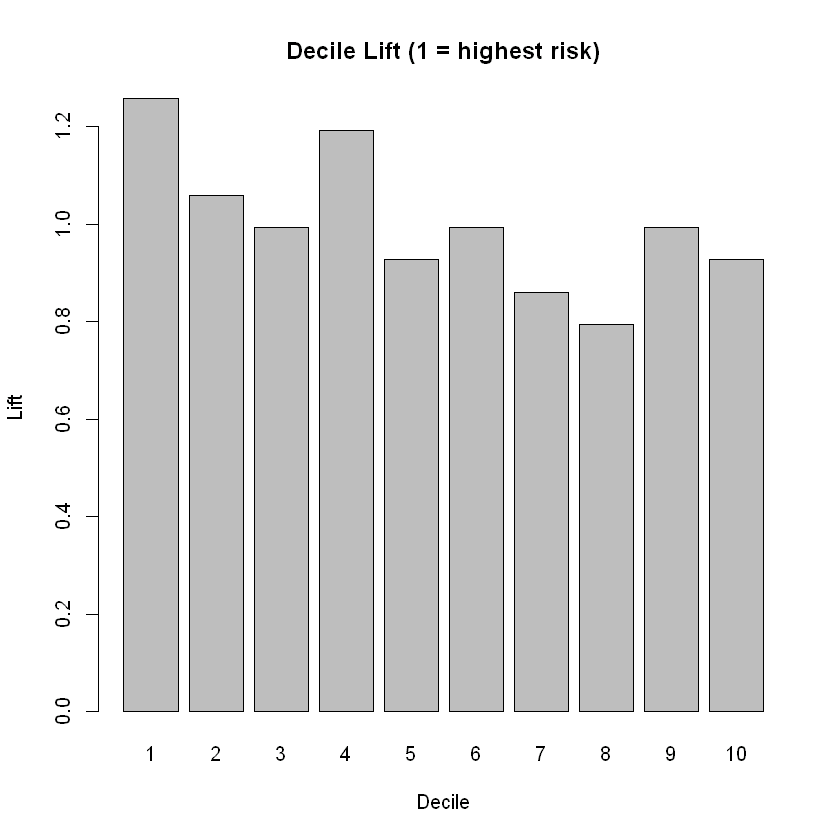

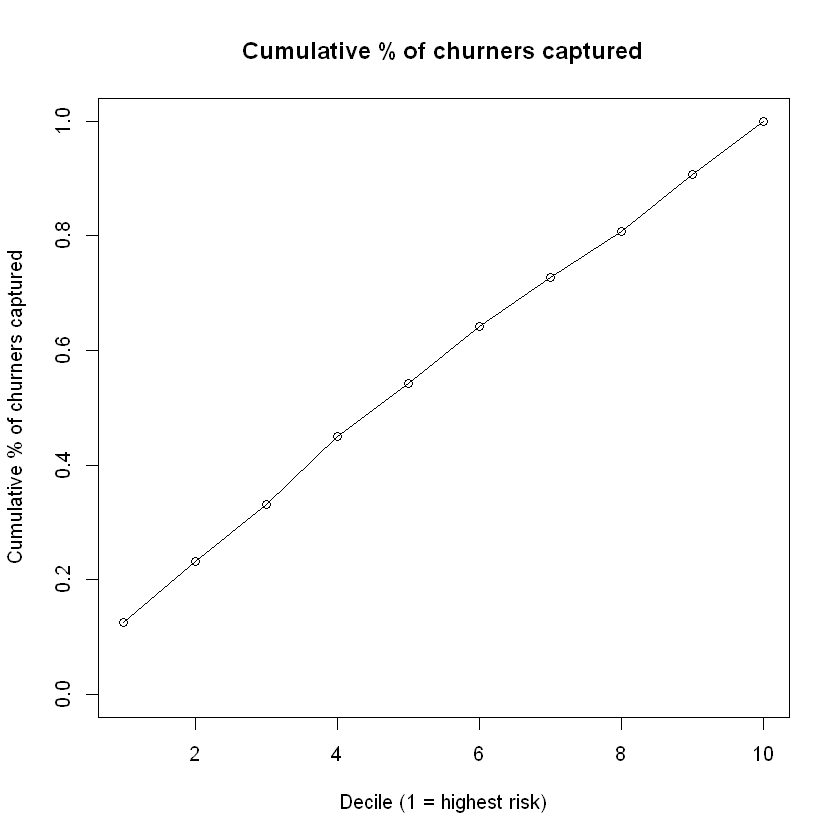

In [45]:
# Question 2b - Divide customers into deciles based on predicted probability, from highest risk to lowest risk

customers <- read.csv("pinnacle_customers.csv", stringsAsFactors = FALSE)
customers <- customers[, names(customers) != "customer_id"]

# Logistic regression model
model <- glm(churned ~., data = customers, family = binomial)
customers$prob_churn <- predict(model, type = "response")

# Overall Baseline churn rate
baseline_churn <- mean(customers$churned)

# Customer sort from highest to lowest risk
customers <- customers[order(-customers$prob_churn), ]

# Now we put customers into 10 equal groups
customers$decile <- rep(1:10, length.out = nrow(customers))

churn_rate_by_decile <- tapply(customers$churned, customers$decile, mean)
churners_by_decile <- tapply(customers$churned, customers$decile, sum)

# Now we make a small table of results
results <- data.frame(
    decile = 1:10, 
    churn_rate = as.numeric(churn_rate_by_decile),
    churners_captured = as.numeric(churners_by_decile)
)
# Lift = decile churn rate / baseline churn rate
results$lift <- results$churn_rate / baseline_churn

# Cumulative % of churners captured
results$cum_churners <- cumsum(results$churners_captured)
results$cum_pct_churners <- results$cum_churners / sum(customers$churned)
results

# Lift chart
barplot(results$lift, names.arg = results$decile, 
        main = "Decile Lift (1 = highest risk)",
        xlab = "Decile", ylab = "Lift")

# Cumulative Gains Chart 
plot(results$decile, results$cum_pct_churners, type = "o",
     main = "Cumulative % of churners captured",
     xlab = "Decile (1 = highest risk)",
     ylab = "Cumulative % of churners captured",
     ylim = c(0, 1))

# Question 2c 
Contacting the top 20% captures 23.2% (35/151) of all churners.
If we contacted a random 20% of members, we can expect to capture 20% of churners. 
Based on this, the model gives a small improvement over random selection. 

In [7]:
# 2d) Cost-benefit: model top 20% vs random 20%

# Top 2 deciles
n <- 2000
contact <- 0.2 * n

# Retention offer cost ($50)
cost <- contact * 50
# Customer Lifetime value of a saved customer ($1200)
clv <- 1200
# Probability os saving contacted churner (30%)
save <- 0.30

# Contact 20% of members (top 2 deciles)
churn_top20 <- 35
churn_total <- 151

net_model <- (churn_top20 * save * clv) - cost
# Random net value 
net_random <- ((0.2 * churn_total) * save * clv) - cost

c(model_cost = cost, model_net = net_model, random_net = net_random)

model_cost  model_net random_net 
     20000      -7400      -9128

 # Question 2d - Compare the two approaches. Should the VP Proceed with the model-targeted campaign?
 The model-targeted campaign is better than random, however both are negative so the VP should not proceed unless the save rate/customer lifetime value increases. 
Reasoning - In our decile results, the top 20% group contains 35 churners. On the other hand, a random 20% would contain only about 30 churners. Because the expected number of saves depends on how many churners you reach. Targeting more churners results in more expected saves and more expected revenue. The model targeted net value (-$7400) is higher than random net value (-$9128). 


In [21]:
# Question 3a - Select numeric features for clustering (excluding customer_id, churned, and any non numeric columns)

cust <- read.csv("pinnacle_customers.csv", stringsAsFactors = FALSE)

# We keep only the numeric columns
num_cols <- names(cust)[sapply(cust, is.numeric)]

# Remove unwanted columns
num_cols <- setdiff(num_cols, c("customer_id", "churned"))

# Nowe we build PCA numeric feature table
x <- cust[, num_cols]
x <- scale(x)

pca <- prcomp(x)
s <- summary(pca)

# Cumulative Variance
s$importance[3, ]

# Now we find the first principle component where cv reaches 70%
k70 <- which(s$importance[3, ] >= 0.70) [1]

pc1 <- sort(abs(pca$rotation[, "PC1"]), decreasing = TRUE)[1:9]
pc2 <- sort(abs(pca$rotation[, "PC2"]), decreasing = TRUE)[1:9]
pc1
pc2 



PC1     PC2     PC3     PC4     PC5     PC6     PC7     PC8     PC9    PC10 
0.37110 0.45777 0.53419 0.59971 0.66160 0.72127 0.77976 0.83107 0.87409 0.91509 
   PC11    PC12    PC13    PC14    PC15    PC16    PC17 
0.93909 0.96094 0.97540 0.98497 0.99373 1.00000 1.00000

total_spent_12mo      spend_apparel       spend_hiking      spend_camping 
         0.3900501          0.3694939          0.3631333          0.3591321 
 spend_accessories             income num_purchases_12mo    avg_order_value 
         0.3523940          0.3209993          0.2750010          0.2562912 
               age 
         0.2487833

pct_online distance_to_store               age   avg_order_value 
       0.67676508        0.63848265        0.24260916        0.12943724 
   household_size     spend_apparel spend_accessories  total_spent_12mo 
       0.11575237        0.10058010        0.09115383        0.07852971 
     spend_hiking 
       0.07737649

# Question 3a 
How many principal components are needed to capture at least 70% of the variance? 
    We would need about 6 principal components because the cumulative variance is at 0.721 for PC6, which would be the first point it is at least 70%.
Examine the loadings of the top 2 PCs. What do they represent? 
    PC1 in this scenario would represent overall spending / customer value. 
    PC2 in this scenario would represents whether customers are more online focused or end up at the store. 

k,total_withinss,avg_silhouette
<dbl>,<dbl>,<dbl>
3,11626.423,0.2486864
4,10585.344,0.2287008
5,9690.334,0.2139437


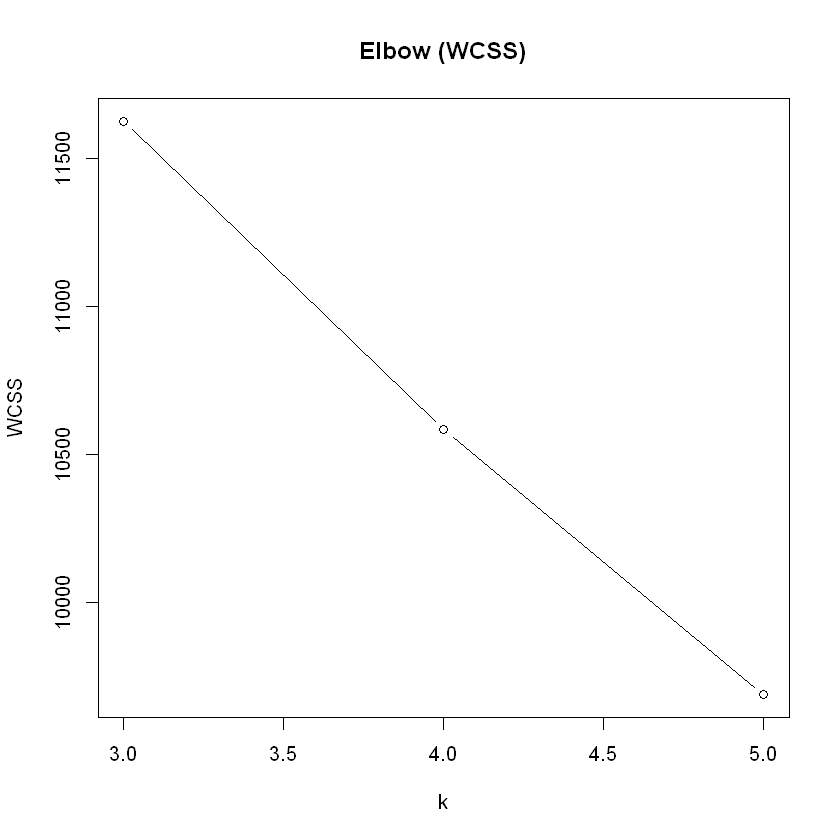

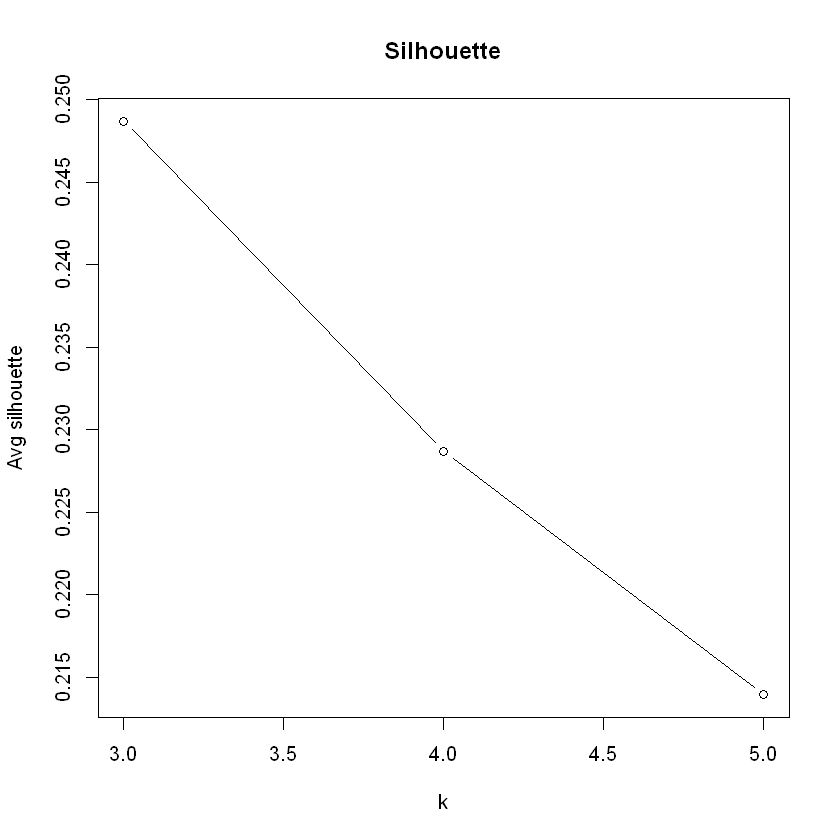

In [47]:
# Question 3b

library(cluster)

# We will use PCA scores for clustering
pcs <- pca$x[, 1:k70]

# wcss - storing total within-cluster sum of squares
# silh = storing average silhouette score
k <- c(3,4,5)
wcss <- c(0,0,0)
silh <- c(0,0,0)

# Loop through the 3 k values
# use n-start = 25
for (i in 1:3) {
  km <- kmeans(pcs, centers = k[i], nstart = 25)
  wcss[i] <- km$tot.withinss
  silh[i] <- mean(silhouette(km$cluster, dist(pcs))[,3])
}

data.frame(k=k, total_withinss=wcss, avg_silhouette=silh)

plot(k, wcss, type="b", main="Elbow (WCSS)", xlab="k", ylab="WCSS")
plot(k, silh, type="b", main="Silhouette", xlab="k", ylab="Avg silhouette")

# Question 3b - Which k do you choose and why?
I choose k = 3 because it has the highest silhouette score (0.2226). The elbow plot  shows us that WCSS keeps dropping as k increases, however the improvement is not worth the drop in cluster quality. This shows us that k = 3 would be the best balance. 

In [75]:
# Question 3c - Cluster Profiling

# Load customer data from the csv
d <- read.csv("pinnacle_customers.csv", stringsAsFactors=FALSE)
d <- d[complete.cases(d), ]

# Take numeric columns only and scale them 
X <- scale(d[, c("age","income","distance_to_store", "household_size","years_member",
                 "total_spent_12mo","num_purchases_12mo","avg_order_value",
                 "spend_camping","spend_hiking","spend_apparel","pct_online")])

# Now we run PCA on the scaled data
p <- prcomp(X)

# We run k-means clustering using the first 6 princpal components
d$cluster <- kmeans(p$x[,1:6], 3, nstart=25)$cluster

# Give each cluster a descriptive business name
seg_names <- c("Premium Hikers","Family Camp Planners","Online Apparel Sites")
d$segment_name <- seg_names[d$cluster]

table(d$segment_name)

# Now we compute the mean age, income and household size for each segment
rbind(
  mean_age = tapply(d$age, d$segment_name, mean),
  mean_income = tapply(d$income, d$segment_name, mean),
  mean_household = tapply(d$household_size, d$segment_name, mean)
)

cats <- c("spend_camping","spend_hiking","spend_apparel","spend_accessories")
top_cat <- tapply(1:nrow(d), d$segment_name, function(i) names(which.max(colMeans(d[i, cats]))))
top_cat


Family Camp Planners Online Apparel Sites       Premium Hikers 
                 444                  906                  650 

,Family Camp Planners,Online Apparel Sites,Premium Hikers
mean_age,48.182432,30.128035,43.004615
mean_income,97605.527027,42246.461369,69796.492308
mean_household,2.603604,2.164459,3.552308


Family Camp Planners Online Apparel Sites       Premium Hikers 
      "spend_hiking"      "spend_apparel"      "spend_camping"

# Question 3d - Recommending a specific market strategy 

Family Camp Planners:

    Channel - Emails

    Product category to feature - Camping 

    Offer Type - Discounts (Percentages)

    The group we are analyzing are relatively under (ages 30) and have the lowest income ($42,265). Based on this, adding a discount right away is most likely to drive the purchase rate. 

Online Apparel Sites:

    Chanel - Social Media

    Product category to feature - Apparel

    Offer Type - Shipping being offered free

    Online shoppers usually browse visually using social media. Free shipping would help convert online cravings into actual purchases. 


Premium Hikers:

    Chanel - Emails
    
    Product category to feature - Hiking

    Offer Type - Giving early access to newly released products

    Premium hikers tend to have the highest income, so the spending would be more as well. Based on that, emails would be the best option in giving out early access to premium hiking gear. 

# Question 4 - Executive Synthesis

To: CEO, Pinnacle Outdoor Co.
From: Akhil Avatapalli
Subject: Churn Targeting, Pricing, Customer Segmentation Analysis - Summary

I hope you are doing well. Pinnacle is a mid sized Canadian outdoor retailer that holds 30 stores with a $45M revenue. However there is three main issues that your company is facing this quarter and that is: seasonal inventory clearanance, loyalty program churn, ineffective mass marketing. I will be attaching the summary of the analysis to help switch these problems around. 


Seasonal Inventory Clearance (Markdown Strategy):
   
    Key Findings: The 10 worst products in week 6 were mainly accessories with a low sell through rate. The sales model shows that a higher price reduces the weekly units sold. However, more web visits increase weekly units sold. 

    Recommended Action: Using targeted markdowns on the worst products is the best advice based on analysis. Cutting prices aggressively for items prices above the successful products in the same category is another strong suggestion. 

Loyalty Program Churn (Who should recieve the offer?):

    Key Findings: The model accuracy turned out to be high, but so did the baseline accuracy because the churner is rare. The decile analysis showed us that the top 20% risk group captures 23.2% of churners. The math behind cost benefit shows us that targeting is better than random, but the expected value can still be negative unless the effectiveness of campaign improves. 

    Recommended Action: If running the campaign, targetting the top 2 deciles (top 20% predicted risk) rather than random would be the best suggestion. First improvements should be with higher save rates, lower offer cost and stronger lifts. 

Ineffective Mass Marketing (Customer Segmentation):

    Key Findings: We got 3 supported segments with PCA + k-means. They all show clear differences betwen age, income, and household size and focuses on categories as well (Hiking, Apparel, Campaign). 

    Recommended Action: Start off with running segment based campaigns. Prioririze focused offers for lower income and light spenders, along with early access to products for high income hikers. 
    
Final Recommendation:

     Use targeted markdowns plus the support of traffic to reduce mass liquidation losses. 
     Transition from mass emails to a 3 segment marketing strategy for better results. 

If you have any other questions based on my analysis, please let me know as I would be more than happy to assist you. Have a great rest of your day.  



Sincerely, 

Akhil Avatapalli
    

# Question 4b - Best Recommendation

Implementing the markdown strategy this quarter is the best recommendation. 

    Clearest ROI - Any unit that fails to sell by week 12 is outsources and liquidated at 25% of the original price. A simple markdown that clears inventory above that level would generate you roughly 2-3x more revenue per unit. The pricing model we got as an output, showed a negative price coefficient, which means a lower price is associated with higher weekly units sold. 

    Does this address your most urgent problem? - Yes it would. Inventory clearance has dealines of 12 week seasons. If that is missed, the price loss is locked in. 

    Easy Implementation - Promotions can be executed immediately, while launching segment marketing usually requires more testing. 
    